# 🚀 Spaceship Titanic - Survival Prediction
Predicting which passengers were transported to another dimension using Machine Learning.
**Best Score: 80.21% accuracy using XGBoost**

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/spaceship-titanic/sample_submission.csv
/kaggle/input/competitions/spaceship-titanic/train.csv
/kaggle/input/competitions/spaceship-titanic/test.csv


## 1. Exploratory Data Analysis
Finding patterns in the data before building any model.
Key finding: CryoSleep passengers are transported 82% of the time!

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('/kaggle/input/competitions/spaceship-titanic/train.csv')

# Basic exploration
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
print("\nFirst 5 rows:")
df.head()

Shape: (8693, 14)

Columns: ['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Name', 'Transported']

Missing values:
 PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

First 5 rows:


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [3]:
print(df.groupby("CryoSleep")["Transported"].mean())

CryoSleep
False    0.328921
True     0.817583
Name: Transported, dtype: float64


In [4]:
# Transportation rate by HomePlanet
print(df.groupby("HomePlanet")["Transported"].mean())
print()

# Transportation rate by VIP
print(df.groupby("VIP")["Transported"].mean())
print()

# Average spending of transported vs not
print(df.groupby("Transported")[["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]].mean())

HomePlanet
Earth     0.423946
Europa    0.658846
Mars      0.523024
Name: Transported, dtype: float64

VIP
False    0.506332
True     0.381910
Name: Transported, dtype: float64

             RoomService   FoodCourt  ShoppingMall         Spa      VRDeck
Transported                                                               
False         389.266066  382.615930    167.566217  564.382666  543.629822
True           63.098021  532.691984    179.829972   61.675531   69.148131


## 2. Data Cleaning
Handling missing values using median for numerical columns and mode for categorical columns.

In [5]:
# Fill missing values
# For numerical columns — fill with median
num_cols = ["Age", "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# For categorical columns — fill with most common value
cat_cols = ["HomePlanet", "CryoSleep", "Destination", "VIP"]
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Check if missing values are gone
print(df.isnull().sum())

PassengerId       0
HomePlanet        0
CryoSleep         0
Cabin           199
Destination       0
Age               0
VIP               0
RoomService       0
FoodCourt         0
ShoppingMall      0
Spa               0
VRDeck            0
Name            200
Transported       0
dtype: int64


/tmp/ipykernel_55/2708246538.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


In [6]:
# Split Cabin into 3 features: Deck, CabinNum, Side
df[["Deck", "CabinNum", "Side"]] = df["Cabin"].str.split("/", expand=True)

# Check what we got
print(df[["Cabin", "Deck", "CabinNum", "Side"]].head())
print("\nUnique Decks:", df["Deck"].unique())
print("Unique Sides:", df["Side"].unique())

   Cabin Deck CabinNum Side
0  B/0/P    B        0    P
1  F/0/S    F        0    S
2  A/0/S    A        0    S
3  A/0/S    A        0    S
4  F/1/S    F        1    S

Unique Decks: ['B' 'F' 'A' 'G' nan 'E' 'D' 'C' 'T']
Unique Sides: ['P' 'S' nan]


In [7]:
print(df.groupby("Deck")["Transported"].mean().sort_values(ascending=False))
print()
print(df.groupby("Side")["Transported"].mean())

Deck
B    0.734275
C    0.680054
G    0.516217
A    0.496094
F    0.439871
D    0.433054
E    0.357306
T    0.200000
Name: Transported, dtype: float64

Side
P    0.451260
S    0.555037
Name: Transported, dtype: float64


In [8]:
# Convert True/False to 1/0
df["CryoSleep"] = df["CryoSleep"].map({True: 1, False: 0})
df["VIP"] = df["VIP"].map({True: 1, False: 0})
df["Transported"] = df["Transported"].map({True: 1, False: 0})

# Convert text categories to numbers
df["HomePlanet"] = df["HomePlanet"].map({"Earth": 0, "Europa": 1, "Mars": 2})
df["Destination"] = df["Destination"].map({"TRAPPIST-1e": 0, "55 Cancri e": 1, "PSO J318.5-22": 2})
df["Side"] = df["Side"].map({"P": 0, "S": 1})
df["Deck"] = df["Deck"].map({"A": 0, "B": 1, "C": 2, "D": 3, "E": 4, "F": 5, "G": 6, "T": 7})

# Fill remaining missing values in Deck and Side
df["Deck"] = df["Deck"].fillna(df["Deck"].median())
df["Side"] = df["Side"].fillna(df["Side"].median())

print("Done!")
print(df[["CryoSleep", "HomePlanet", "Deck", "Side", "Transported"]].head())

Done!
   CryoSleep  HomePlanet  Deck  Side  Transported
0          0           1   1.0   0.0            0
1          0           0   5.0   1.0            1
2          0           1   0.0   1.0            0
3          0           1   0.0   1.0            0
4          0           0   5.0   1.0            1


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Select features
features = ["HomePlanet", "CryoSleep", "Destination", "Age", "VIP",
            "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck",
            "Deck", "Side"]

X = df[features]
y = df["Transported"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7814836112708453


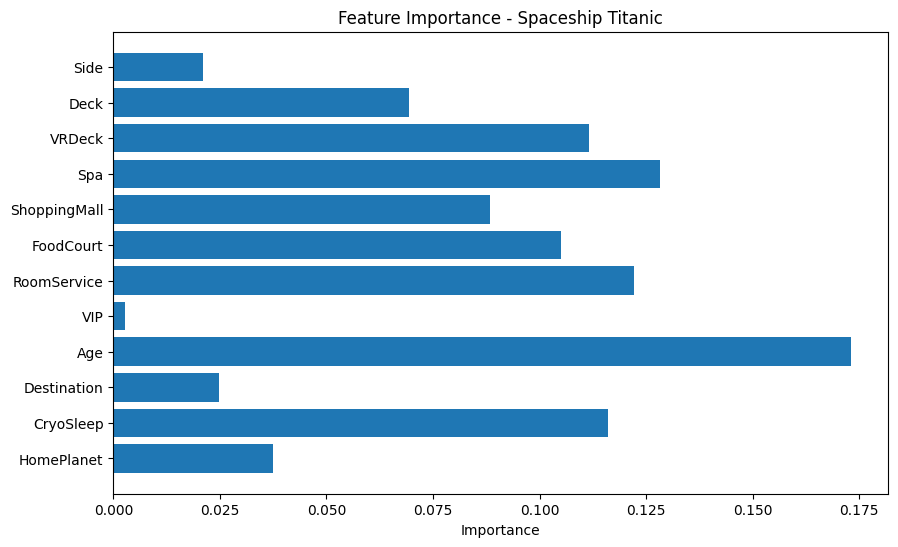

In [10]:
import matplotlib.pyplot as plt

importance = model.feature_importances_
plt.figure(figsize=(10, 6))
plt.barh(features, importance)
plt.xlabel("Importance")
plt.title("Feature Importance - Spaceship Titanic")
plt.show()

In [11]:
# Create total spending feature
df["TotalSpend"] = df["RoomService"] + df["FoodCourt"] + df["ShoppingMall"] + df["Spa"] + df["VRDeck"]

# Check if it correlates with transportation
print(df.groupby("Transported")["TotalSpend"].mean())

Transported
0    2004.149247
1     885.689127
Name: TotalSpend, dtype: float64


In [12]:
# Add TotalSpend to test data too (we'll need it later)
# For now retrain with new feature

features_v2 = ["HomePlanet", "CryoSleep", "Destination", "Age", "VIP",
                "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck",
                "Deck", "Side", "TotalSpend"]  # added TotalSpend!

X2 = df[features_v2]
y2 = df["Transported"]

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

model_v2 = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model_v2.fit(X2_train, y2_train)

y2_pred = model_v2.predict(X2_test)
print("V1 Accuracy:", accuracy_score(y_test, y_pred))
print("V2 Accuracy:", accuracy_score(y2_test, y2_pred))

V1 Accuracy: 0.7814836112708453
V2 Accuracy: 0.7837837837837838


In [13]:
model_v3 = RandomForestClassifier(n_estimators=500,  # increased from 100 to 500
                                   random_state=42, 
                                   class_weight='balanced')
model_v3.fit(X2_train, y2_train)

y3_pred = model_v3.predict(X2_test)
print("V2 Accuracy:", accuracy_score(y2_test, y2_pred))
print("V3 Accuracy:", accuracy_score(y2_test, y3_pred))

V2 Accuracy: 0.7837837837837838
V3 Accuracy: 0.7791834387579069


In [14]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
model_xgb.fit(X2_train, y2_train)

y_xgb_pred = model_xgb.predict(X2_test)
print("Random Forest V2:", accuracy_score(y2_test, y2_pred))
print("XGBoost:", accuracy_score(y2_test, y_xgb_pred))

Random Forest V2: 0.7837837837837838
XGBoost: 0.7872340425531915


In [15]:
model_xgb_v2 = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)
model_xgb_v2.fit(X2_train, y2_train)

y_xgb_v2_pred = model_xgb_v2.predict(X2_test)
print("Random Forest V2:", accuracy_score(y2_test, y2_pred))
print("XGBoost V1:", accuracy_score(y2_test, y_xgb_pred))
print("XGBoost V2:", accuracy_score(y2_test, y_xgb_v2_pred))

Random Forest V2: 0.7837837837837838
XGBoost V1: 0.7872340425531915
XGBoost V2: 0.7993099482461185


In [16]:
# Passengers with zero total spend are likely in CryoSleep
df["IsSpendZero"] = (df["TotalSpend"] == 0).astype(int)
print(df.groupby("IsSpendZero")["Transported"].mean())

IsSpendZero
0    0.298611
1    0.786477
Name: Transported, dtype: float64


In [17]:
# Add IsSpendZero to features
features_v3 = ["HomePlanet", "CryoSleep", "Destination", "Age", "VIP",
                "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck",
                "Deck", "Side", "TotalSpend", "IsSpendZero"]

X3 = df[features_v3]
y3 = df["Transported"]

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42)

model_xgb_v3 = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)
model_xgb_v3.fit(X3_train, y3_train)

y_xgb_v3_pred = model_xgb_v3.predict(X3_test)
print("XGBoost V2:", accuracy_score(y2_test, y_xgb_v2_pred))
print("XGBoost V3:", accuracy_score(y3_test, y_xgb_v3_pred))

XGBoost V2: 0.7993099482461185
XGBoost V3: 0.7947096032202415


In [18]:
# Extract group from PassengerId
df["Group"] = df["PassengerId"].str.split("_").str[0]
df["GroupSize"] = df.groupby("Group")["Group"].transform("count")

print(df["GroupSize"].value_counts())
print()
print(df.groupby("GroupSize")["Transported"].mean())

GroupSize
1    4805
2    1682
3    1020
4     412
5     265
7     231
6     174
8     104
Name: count, dtype: int64

GroupSize
1    0.452445
2    0.538050
3    0.593137
4    0.640777
5    0.592453
6    0.614943
7    0.541126
8    0.394231
Name: Transported, dtype: float64


In [19]:
features_v4 = ["HomePlanet", "CryoSleep", "Destination", "Age", "VIP",
                "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck",
                "Deck", "Side", "TotalSpend", "GroupSize"]

X4 = df[features_v4]
y4 = df["Transported"]

X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y4, test_size=0.2, random_state=42)

model_xgb_v4 = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)
model_xgb_v4.fit(X4_train, y4_train)

y_xgb_v4_pred = model_xgb_v4.predict(X4_test)
print("XGBoost V2 (best):", accuracy_score(y2_test, y_xgb_v2_pred))
print("XGBoost V4 (+GroupSize):", accuracy_score(y4_test, y_xgb_v4_pred))

XGBoost V2 (best): 0.7993099482461185
XGBoost V4 (+GroupSize): 0.7987349051178838


In [20]:
model_xgb_v5 = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,  # slower learning
    subsample=0.85,
    colsample_bytree=0.75,
    min_child_weight=3,
    gamma=0.1,
    random_state=42,
    eval_metric='logloss'
)
model_xgb_v5.fit(X2_train, y2_train)

y_xgb_v5_pred = model_xgb_v5.predict(X2_test)
print("XGBoost V2 (best):", accuracy_score(y2_test, y_xgb_v2_pred))
print("XGBoost V5 (tuned):", accuracy_score(y2_test, y_xgb_v5_pred))

XGBoost V2 (best): 0.7993099482461185
XGBoost V5 (tuned): 0.7952846463484762


In [21]:
from sklearn.ensemble import VotingClassifier, GradientBoostingClassifier

# Three different models voting together
model_gb = GradientBoostingClassifier(n_estimators=200, max_depth=5, 
                                       learning_rate=0.1, random_state=42)
model_gb.fit(X2_train, y2_train)
y_gb_pred = model_gb.predict(X2_test)
print("Gradient Boosting:", accuracy_score(y2_test, y_gb_pred))
print("XGBoost V2 (best):", accuracy_score(y2_test, y_xgb_v2_pred))

Gradient Boosting: 0.7935595169637722
XGBoost V2 (best): 0.7993099482461185


In [22]:
print(df.groupby("Deck")[["RoomService", "FoodCourt", "Spa", "TotalSpend"]].mean().round(2))

      RoomService  FoodCourt      Spa  TotalSpend
Deck                                             
0.0        133.04    1541.54   693.25     3402.30
1.0         84.15    1238.56   714.47     2927.83
2.0        178.02    1788.61   905.38     4105.91
3.0        660.02     581.58   460.83     2289.52
4.0        306.69     263.06   265.13     1298.77
5.0        304.33     162.86   183.72     1027.66
6.0         71.44      78.08    87.92      381.04
7.0        427.20    1397.40  2008.40     4716.40


In [23]:
df["DeckClass"] = df["Deck"].map({
    0: 2,  # A → upper
    1: 1,  # B → middle
    2: 2,  # C → upper
    3: 1,  # D → middle
    4: 1,  # E → middle
    5: 1,  # F → middle
    6: 0,  # G → lower
    7: 2   # T → upper
})

print(df.groupby("DeckClass")["Transported"].mean())

DeckClass
0    0.516217
1    0.472298
2    0.630952
Name: Transported, dtype: float64


In [24]:
# Add all unused features
df["CabinNum"] = df["CabinNum"].astype(float)
df["IsAlone"] = (df["GroupSize"] == 1).astype(int)
df["AgeBin"] = pd.cut(df["Age"], bins=[0, 12, 18, 35, 60, 100], labels=[0, 1, 2, 3, 4])
df["AgeBin"] = df["AgeBin"].astype(float)

features_v7 = ["HomePlanet", "CryoSleep", "Destination", "Age", "VIP",
                "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck",
                "Deck", "Side", "TotalSpend", "DeckClass", 
                "CabinNum", "IsAlone", "AgeBin", "GroupSize"]

X7 = df[features_v7]
y7 = df["Transported"]

X7_train, X7_test, y7_train, y7_test = train_test_split(X7, y7, test_size=0.2, random_state=42)

model_xgb_v7 = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)
model_xgb_v7.fit(X7_train, y7_train)

y_xgb_v7_pred = model_xgb_v7.predict(X7_test)
print("XGBoost V2 (best so far):", accuracy_score(y2_test, y_xgb_v2_pred))
print("XGBoost V7 (all features):", accuracy_score(y7_test, y_xgb_v7_pred))

XGBoost V2 (best so far): 0.7993099482461185
XGBoost V7 (all features): 0.8016101207590569


In [25]:
features_v8 = ["HomePlanet", "CryoSleep", "Destination", "Age",
                "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck",
                "Deck", "Side", "TotalSpend", "CabinNum"]

X8 = df[features_v8]
y8 = df["Transported"]

X8_train, X8_test, y8_train, y8_test = train_test_split(X8, y8, test_size=0.2, random_state=42)

model_xgb_v8 = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)
model_xgb_v8.fit(X8_train, y8_train)

y_xgb_v8_pred = model_xgb_v8.predict(X8_test)
print("XGBoost V7 (80.16%):", accuracy_score(y7_test, y_xgb_v7_pred))
print("XGBoost V8 (dropped weak):", accuracy_score(y8_test, y_xgb_v8_pred))

XGBoost V7 (80.16%): 0.8016101207590569
XGBoost V8 (dropped weak): 0.7993099482461185


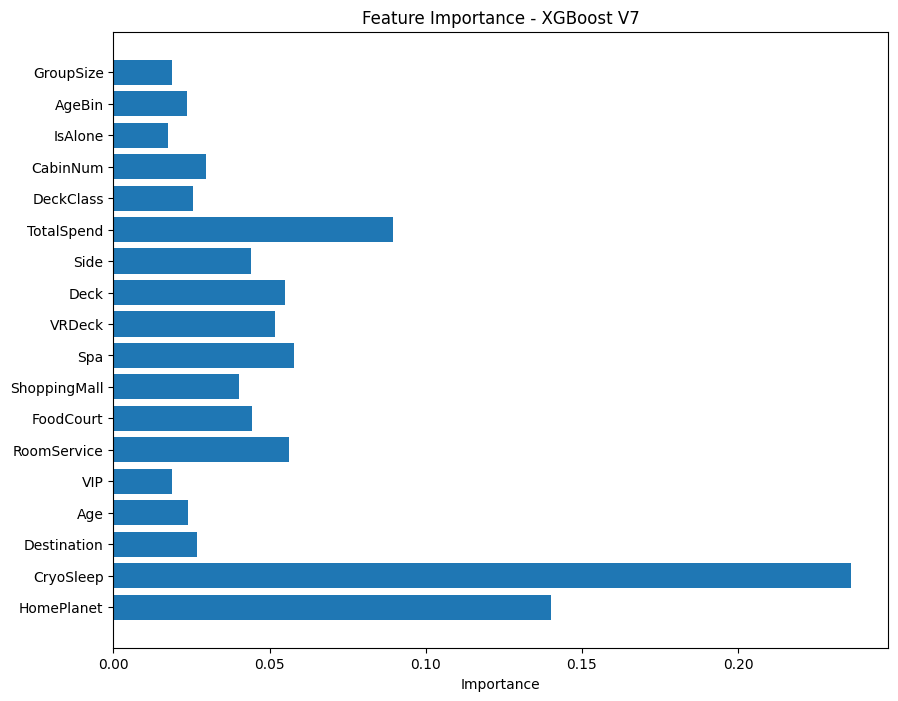

In [26]:
import matplotlib.pyplot as plt

importance = model_xgb_v7.feature_importances_
plt.figure(figsize=(10, 8))
plt.barh(features_v7, importance)
plt.xlabel("Importance")
plt.title("Feature Importance - XGBoost V7")
plt.show()

In [27]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [200, 300, 400],
    'max_depth': [4, 5, 6],
    'learning_rate': [0.05, 0.1, 0.15],
    'subsample': [0.8, 0.85, 0.9],
}

grid_search = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X7_train, y7_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

# Test on our test set
best_model = grid_search.best_estimator_
y_best_pred = best_model.predict(X7_test)
print("Test accuracy:", accuracy_score(y7_test, y_best_pred))

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 400, 'subsample': 0.9}
Best CV score: 0.8121946325039179
Test accuracy: 0.8021851638872916


In [28]:
# Check training accuracy vs test accuracy
train_pred = best_model.predict(X7_train)
test_pred = best_model.predict(X7_test)

print("Training accuracy:", accuracy_score(y7_train, train_pred))
print("Test accuracy:", accuracy_score(y7_test, test_pred))

Training accuracy: 0.8668392292205924
Test accuracy: 0.8021851638872916


In [29]:
model_final = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.8,
    min_child_weight=5,    # increased → less overfitting
    gamma=0.2,             # increased → more conservative
    reg_alpha=0.1,         # L1 regularization → penalizes complexity
    reg_lambda=1.5,        # L2 regularization → penalizes complexity
    random_state=42,
    eval_metric='logloss'
)

model_final.fit(X7_train, y7_train)

train_pred = model_final.predict(X7_train)
test_pred = model_final.predict(X7_test)

print("Training accuracy:", accuracy_score(y7_train, train_pred))
print("Test accuracy:", accuracy_score(y7_test, test_pred))

Training accuracy: 0.8582111015243026
Test accuracy: 0.8004600345025877


In [30]:
from sklearn.model_selection import train_test_split

# Split training data further into train and validation
X7_train2, X7_val, y7_train2, y7_val = train_test_split(X7_train, y7_train, 
                                                          test_size=0.2, 
                                                          random_state=42)

model_es = XGBClassifier(
    n_estimators=1000,      # high number, early stopping will cut it
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.2,
    reg_alpha=0.1,
    reg_lambda=1.5,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=50  # stop if no improvement for 50 rounds
)

model_es.fit(X7_train2, y7_train2,
             eval_set=[(X7_val, y7_val)],
             verbose=False)

print("Best iteration:", model_es.best_iteration)
train_pred = model_es.predict(X7_train)
test_pred = model_es.predict(X7_test)
print("Training accuracy:", accuracy_score(y7_train, train_pred))
print("Test accuracy:", accuracy_score(y7_test, test_pred))

Best iteration: 350
Training accuracy: 0.8468507333908541
Test accuracy: 0.7993099482461185


In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Fill remaining NaN values
X7_train_clean = X7_train.fillna(X7_train.median())
X7_test_clean = X7_test.fillna(X7_test.median())

# Scale and train
scaler = StandardScaler()
X7_train_scaled = scaler.fit_transform(X7_train_clean)
X7_test_scaled = scaler.transform(X7_test_clean)

model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X7_train_scaled, y7_train)

train_pred_lr = model_lr.predict(X7_train_scaled)
test_pred_lr = model_lr.predict(X7_test_scaled)

print("Logistic Regression:")
print("Training accuracy:", accuracy_score(y7_train, train_pred_lr))
print("Test accuracy:", accuracy_score(y7_test, test_pred_lr))

# Fill remaining NaN values
X7_train_clean = X7_train.fillna(X7_train.median())
X7_test_clean = X7_test.fillna(X7_test.median())

# Scale and train
scaler = StandardScaler()
X7_train_scaled = scaler.fit_transform(X7_train_clean)
X7_test_scaled = scaler.transform(X7_test_clean)

model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X7_train_scaled, y7_train)

train_pred_lr = model_lr.predict(X7_train_scaled)
test_pred_lr = model_lr.predict(X7_test_scaled)

print("Logistic Regression:")
print("Training accuracy:", accuracy_score(y7_train, train_pred_lr))
print("Test accuracy:", accuracy_score(y7_test, test_pred_lr))
print("Gap:", round(accuracy_score(y7_train, train_pred_lr) - accuracy_score(y7_test, test_pred_lr), 4))
print()
print("XGBoost (best):")
print("Training accuracy: 0.8668")
print("Test accuracy: 0.8021")
print("Gap: 0.0647")

Logistic Regression:
Training accuracy: 0.7911993097497843
Test accuracy: 0.7745830937320299
Logistic Regression:
Training accuracy: 0.7911993097497843
Test accuracy: 0.7745830937320299
Gap: 0.0166

XGBoost (best):
Training accuracy: 0.8668
Test accuracy: 0.8021
Gap: 0.0647


In [32]:
# Load test data
test_df = pd.read_csv('/kaggle/input/competitions/spaceship-titanic/test.csv')

# Apply same cleaning steps
for col in ["Age", "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]:
    test_df[col] = test_df[col].fillna(test_df[col].median())

for col in ["HomePlanet", "CryoSleep", "Destination", "VIP"]:
    test_df[col] = test_df[col].fillna(test_df[col].mode()[0])

test_df[["Deck", "CabinNum", "Side"]] = test_df["Cabin"].str.split("/", expand=True)

test_df["CryoSleep"] = test_df["CryoSleep"].map({True: 1, False: 0})
test_df["VIP"] = test_df["VIP"].map({True: 1, False: 0})
test_df["HomePlanet"] = test_df["HomePlanet"].map({"Earth": 0, "Europa": 1, "Mars": 2})
test_df["Destination"] = test_df["Destination"].map({"TRAPPIST-1e": 0, "55 Cancri e": 1, "PSO J318.5-22": 2})
test_df["Side"] = test_df["Side"].map({"P": 0, "S": 1})
test_df["Deck"] = test_df["Deck"].map({"A": 0, "B": 1, "C": 2, "D": 3, "E": 4, "F": 5, "G": 6, "T": 7})
test_df["Deck"] = test_df["Deck"].fillna(test_df["Deck"].median())
test_df["Side"] = test_df["Side"].fillna(test_df["Side"].median())
test_df["CabinNum"] = test_df["CabinNum"].astype(float)
test_df["TotalSpend"] = test_df["RoomService"] + test_df["FoodCourt"] + test_df["ShoppingMall"] + test_df["Spa"] + test_df["VRDeck"]
test_df["Group"] = test_df["PassengerId"].str.split("_").str[0]
test_df["GroupSize"] = test_df.groupby("Group")["Group"].transform("count")
test_df["IsAlone"] = (test_df["GroupSize"] == 1).astype(int)
test_df["AgeBin"] = pd.cut(test_df["Age"], bins=[0, 12, 18, 35, 60, 100], labels=[0, 1, 2, 3, 4])
test_df["AgeBin"] = test_df["AgeBin"].astype(float)
test_df["DeckClass"] = test_df["Deck"].map({0:2, 1:1, 2:2, 3:1, 4:1, 5:1, 6:0, 7:2})

print("Test data ready!")
print(test_df.shape)

Test data ready!
(4277, 22)


/tmp/ipykernel_55/3427795965.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_df[col] = test_df[col].fillna(test_df[col].mode()[0])


In [33]:
# XGBoost submission
xgb_predictions = best_model.predict(test_df[features_v7])
xgb_submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Transported": xgb_predictions.astype(bool)
})
xgb_submission.to_csv("submission_xgboost.csv", index=False)
print("XGBoost submission created!")
print(xgb_submission.head())

# Logistic Regression submission
test_clean = test_df[features_v7].fillna(test_df[features_v7].median())
test_scaled = scaler.transform(test_clean)
lr_predictions = model_lr.predict(test_scaled)
lr_submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Transported": lr_predictions.astype(bool)
})
lr_submission.to_csv("submission_lr.csv", index=False)
print("\nLogistic Regression submission created!")
print(lr_submission.head())

XGBoost submission created!
  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01         True

Logistic Regression submission created!
  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01         True


In [35]:
from xgboost import XGBClassifier

# XGBoost submission
xgb_predictions = best_model.predict(test_df[features_v7])
xgb_submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Transported": xgb_predictions.astype(bool)
})
xgb_submission.to_csv("/kaggle/working/submission_xgboost.csv", index=False)
print("XGBoost submission created!")

# Logistic Regression submission
test_clean = test_df[features_v7].fillna(test_df[features_v7].median())
test_scaled = scaler.transform(test_clean)
lr_predictions = model_lr.predict(test_scaled)
lr_submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Transported": lr_predictions.astype(bool)
})
lr_submission.to_csv("/kaggle/working/submission_lr.csv", index=False)
print("Logistic Regression submission created!")

XGBoost submission created!
Logistic Regression submission created!


In [36]:
# Hypertuned XGBoost submission
hyper_predictions = best_model.predict(test_df[features_v7])
hyper_submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Transported": hyper_predictions.astype(bool)
})
hyper_submission.to_csv("/kaggle/working/submission_hypertuned.csv", index=False)
print("Hypertuned submission created!")

Hypertuned submission created!
